# 02.3 — Derivatives & Gradients

**Phase:** 02 — Mathematics for ML

**Difficulty:** Beginner–Intermediate

**Priority:** Core — everything in optimization depends on this

**Status:** VERIFIED

---

## 1. What Are We Solving?

Machine learning is fundamentally **optimization**: find the model parameters that minimize a loss function. But how do you know which direction to adjust the parameters?

**Derivatives** answer this question. They tell you the slope of a function — which direction to move to reduce the loss. **Gradients** generalize this to multiple variables (which is most ML, since models have many parameters).

Without derivatives, you'd have to guess blindly. With them, you know exactly how to improve.

## 2. Why Does This Matter?

Every neural network is trained using **gradient descent**, which repeatedly computes the gradient of the loss and adjusts parameters in the opposite direction. This requires:
- **Derivatives**: understanding slope for single-variable functions
- **Partial derivatives**: how does the loss change when I tweak *this one* weight?
- **Gradients**: the full vector of partial derivatives — the direction of steepest increase
- **Chain rule**: how to compute gradients through compositions of functions (backpropagation)
- **Automatic differentiation**: how PyTorch/TensorFlow compute gradients efficiently

## 3. Prerequisites

- Unit 02.1 (Vectors & Matrices)
- Unit 02.2 (Matrix Operations)
- Basic Python functions

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- [ ] Explain what a derivative measures and compute it numerically
- [ ] Compute partial derivatives of multi-variable functions
- [ ] Understand the gradient vector and its geometric meaning
- [ ] Apply the chain rule to composite functions
- [ ] Use PyTorch autograd to compute gradients automatically
- [ ] Recognize the vanishing gradient problem and know why ReLU helps

## 5. Mental Model

Imagine you're standing on a hilly landscape in fog. You want to get to the lowest point. The **gradient** tells you which direction is *steepest uphill*. If you walk in the **opposite direction**, you'll go downhill as fast as possible.

The **derivative** at any point is the slope of the ground right where you're standing. The **gradient** combines all the partial slopes (one per dimension) into a single direction vector.

This is exactly how neural networks learn: compute the gradient of the loss with respect to each weight, then take a small step in the opposite direction.

## 6. Core Concepts: What is a Derivative?

The **derivative** `f'(x)` measures the instantaneous rate of change of `f` at point `x`. It answers: "If I nudge `x` a tiny bit, how much does `f(x)` change?"

```
f'(x) = lim(h→0) [f(x+h) - f(x)] / h

Geometrically: the slope of the tangent line at x
```

**Examples:**
```
f(x) = x²      →  f'(x) = 2x       (slope at x=3 is 6)
f(x) = eˣ      →  f'(x) = eˣ       (slope equals the function itself)
f(x) = ln(x)   →  f'(x) = 1/x      (slope decreases as x grows)
f(x) = sin(x)  →  f'(x) = cos(x)   (slope oscillates)
```

**What it means for ML:**
- If the loss `L(w)` has a large positive derivative at weight `w`, increasing `w` will increase the loss → decrease `w` to improve
- If the derivative is near 0, you're at a minimum (or flat region) → learning slows down

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical derivative
def f(x):
    return x**2  # f'(x) = 2x

def numerical_derivative(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

# At x=3, f'(3) = 2*3 = 6
x = 3.0
deriv = numerical_derivative(f, x)
print(f"f(x) = x^2")
print(f"Numerical derivative at x={x}: {deriv:.6f}")
print(f"Analytical derivative (2x): {2 * x}")
print(f"Match: {abs(deriv - 2 * x) < 1e-4}")

f(x) = x^2
Numerical derivative at x=3.0: 6.000000
Analytical derivative (2x): 6.0
Match: True


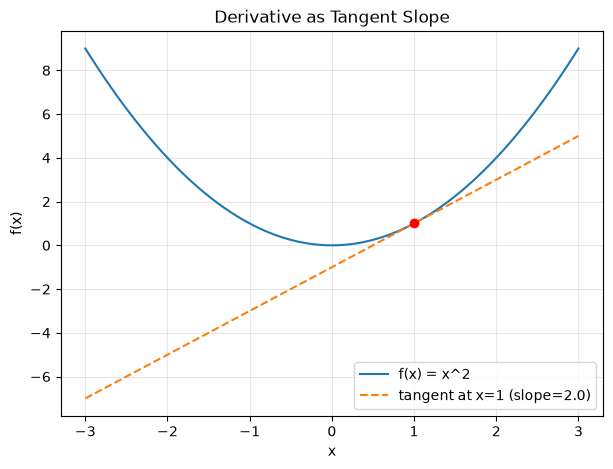

In [2]:
# Visualize the derivative as the slope of the tangent line
x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)

# Tangent line at x=1
x0 = 1.0
slope = 2 * x0  # f'(1) = 2
tangent = slope * (x_vals - x0) + f(x0)

plt.figure(figsize=(7, 5))
plt.plot(x_vals, y_vals, label="f(x) = x^2")
plt.plot(x_vals, tangent, "--", label=f"tangent at x=1 (slope={slope})")
plt.scatter([x0], [f(x0)], color="red", zorder=5)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Derivative as Tangent Slope")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Common Derivatives

| Function | Derivative |
|----------|-----------|
| `xⁿ` | `n·xⁿ⁻¹` |
| `eˣ` | `eˣ` |
| `ln(x)` | `1/x` |
| `sin(x)` | `cos(x)` |
| `cos(x)` | `-sin(x)` |
| `c·f(x)` | `c·f'(x)` |
| `f(x)+g(x)` | `f'(x)+g'(x)` |

Let's verify a few numerically.

In [3]:
# Verify common derivatives numerically
def numerical_derivative(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

x = 2.0

# d/dx x^3 = 3x^2
num = numerical_derivative(lambda t: t**3, x)
ana = 3 * x**2
print(f"d/dx x^3 at x=2: num={num:.4f}, ana={ana:.4f}")

# d/dx e^x = e^x
num = numerical_derivative(lambda t: np.exp(t), x)
ana = np.exp(x)
print(f"d/dx e^x at x=2: num={num:.4f}, ana={ana:.4f}")

# d/dx ln(x) = 1/x
num = numerical_derivative(lambda t: np.log(t), x)
ana = 1 / x
print(f"d/dx ln(x) at x=2: num={num:.4f}, ana={ana:.4f}")

d/dx x^3 at x=2: num=12.0000, ana=12.0000
d/dx e^x at x=2: num=7.3891, ana=7.3891
d/dx ln(x) at x=2: num=0.5000, ana=0.5000


## 8. Partial Derivatives

Most ML functions have **multiple inputs** (weights). The **partial derivative** answers: "How does the output change when I tweak *one* variable, keeping all others fixed?"

```
f(x, y) = x² + 3xy + y²

∂f/∂x = 2x + 3y    (treat y as constant, differentiate w.r.t. x)
∂f/∂y = 3x + 2y    (treat x as constant, differentiate w.r.t. y)

At (x=2, y=3):
  ∂f/∂x = 2(2) + 3(3) = 13
  ∂f/∂y = 3(2) + 2(3) = 12
```

**In ML:** Each weight `wᵢ` in a model has its own partial derivative `∂L/∂wᵢ` — how much the loss changes if you nudge that one weight.

In [4]:
# Partial derivatives
# f(x, y) = x^2 + 3xy + y^2
# df/dx = 2x + 3y
# df/dy = 3x + 2y

def f(x, y):
    return x**2 + 3 * x * y + y**2

def partial_x(f, x, y, h=1e-6):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

x, y = 2.0, 3.0

num_dx = partial_x(f, x, y)
ana_dx = 2 * x + 3 * y  # = 4 + 9 = 13
print(f"df/dx at (2,3): num={num_dx:.4f}, ana={ana_dx:.4f}")

num_dy = partial_y(f, x, y)
ana_dy = 3 * x + 2 * y  # = 6 + 6 = 12
print(f"df/dy at (2,3): num={num_dy:.4f}, ana={ana_dy:.4f}")

df/dx at (2,3): num=13.0000, ana=13.0000
df/dy at (2,3): num=12.0000, ana=12.0000


## 9. The Gradient

The **gradient** is the vector of all partial derivatives. It tells you the direction of **steepest increase**.

```
∇f = [∂f/∂x₁, ∂f/∂x₂, ..., ∂f/∂xₙ]

For f(x, y) = x² + y²:
∇f = [2x, 2y]

At point (3, 4):  ∇f = [6, 8]
  → the function increases fastest in direction [6, 8]
  → to minimize, move in direction [-6, -8]
```

**The key insight for ML:** The gradient of the loss with respect to the weights, `∇L(w)`, tells you exactly which direction to adjust the weights to reduce the loss. Gradient descent follows this direction:
```
w_new = w_old - learning_rate × ∇L(w_old)
                ↑                        ↑
            step size          direction of steepest decrease
```

In [5]:
# Gradient of f(x, y) = x^2 + y^2
# grad = [2x, 2y]

def gradient(f, x, y, h=1e-6):
    dfdx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    dfdy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return np.array([dfdx, dfdy])

def f(x, y):
    return x**2 + y**2

point = np.array([3.0, 4.0])
grad = gradient(f, point[0], point[1])
print(f"Gradient at {point}: {grad}")
print(f"Analytical gradient: {2 * point}")
print(f"\nThe gradient points in the direction of steepest increase.")
print(f"To minimize, move in direction {-grad} (opposite the gradient).")

Gradient at [3. 4.]: [6. 8.]
Analytical gradient: [6. 8.]

The gradient points in the direction of steepest increase.
To minimize, move in direction [-6. -8.] (opposite the gradient).


## 10. The Chain Rule

Neural networks are **compositions** of functions: one layer feeds into the next. The **chain rule** lets us differentiate through these compositions.

```
If h(x) = f(g(x)), then:
h'(x) = f'(g(x)) · g'(x)

Example: h(x) = (3x + 1)²
  Let g(x) = 3x + 1  →  g'(x) = 3
  Let f(u) = u²      →  f'(u) = 2u
  h'(x) = 2(3x+1) · 3 = 6(3x+1)

  At x=2: h'(2) = 6 · 7 = 42
```

**In neural networks (backpropagation):**
Each layer is a function of the previous layer's output. The chain rule lets us compute `∂Loss/∂weight` by multiplying the gradients through each layer:
```
∂L/∂w₁ = ∂L/∂a₃ · ∂a₃/∂a₂ · ∂a₂/∂a₁ · ∂a₁/∂w₁
          ↑       ↑       ↑       ↑       ↑
       loss    layer3  layer2  layer1  layer1
       grad    grad    grad    grad    grad
```

In [6]:
# Chain rule
# h(x) = (3x + 1)^2
# Let g(x) = 3x + 1, f(u) = u^2
# h'(x) = f'(g(x)) * g'(x) = 2(3x+1) * 3 = 6(3x+1)

def h(x):
    return (3 * x + 1) ** 2

def numerical_derivative(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

x = 2.0
num = numerical_derivative(h, x)
ana = 6 * (3 * x + 1)  # = 6 * 7 = 42
print(f"h'(2) numerical: {num:.4f}")
print(f"h'(2) chain rule: {ana:.4f}")
print(f"Match: {abs(num - ana) < 1e-4}")

h'(2) numerical: 42.0000
h'(2) chain rule: 42.0000
Match: True


## 11. Automatic Differentiation (PyTorch)

PyTorch computes gradients automatically via **autograd**. This is how neural networks learn — no manual derivative math needed.

In [7]:
import torch

# Automatic differentiation with PyTorch
x = torch.tensor(3.0, requires_grad=True)
y = x**2  # dy/dx = 2x = 6

y.backward()
print(f"x: {x.item()}")
print(f"y = x^2: {y.item()}")
print(f"dy/dx (autograd): {x.grad.item()}")
print(f"Expected: 6.0")

x: 3.0
y = x^2: 9.0
dy/dx (autograd): 6.0
Expected: 6.0


In [8]:
# Gradient of a multi-variable function with PyTorch
# f(x, y) = x^2 + 3xy + y^2
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
f = x**2 + 3 * x * y + y**2

f.backward()
print(f"f: {f.item()}")
print(f"df/dx: {x.grad.item()} (expected 13.0)")
print(f"df/dy: {y.grad.item()} (expected 12.0)")

f: 31.0
df/dx: 13.0 (expected 13.0)
df/dy: 12.0 (expected 12.0)


## 12. Experiment: Gradient of a Loss Function

This is what actually happens during training. We compute the gradient of the loss with respect to each model parameter, then use those gradients to update the parameters.

```
Loss = (1/n) Σ (y_pred - y_true)²
y_pred = w * x + b

After backward(), we get:
  ∂Loss/∂w  →  how to adjust the weight
  ∂Loss/∂b  →  how to adjust the bias
```

The negative gradient tells us the direction to move `w` and `b` to reduce the loss.

In [9]:
# Gradient of MSE loss
# Loss = (1/n) * sum((y_pred - y)^2), where y_pred = w*x + b

np.random.seed(42)
X = np.random.randn(50)
y_true = 2 * X + 1

# Model parameters (to be optimized)
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Convert data to tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y_true, dtype=torch.float32)

# Forward pass
y_pred = w * X_t + b
loss = torch.mean((y_pred - y_t) ** 2)

# Backward pass (compute gradients)
loss.backward()

print(f"Loss: {loss.item():.4f}")
print(f"dLoss/dw: {w.grad.item():.4f}")
print(f"dLoss/db: {b.grad.item():.4f}")
print("\nThese gradients tell us how to adjust w and b to reduce the loss.")

Loss: 3.7187
dLoss/dw: -3.1696
dLoss/db: -1.0981

These gradients tell us how to adjust w and b to reduce the loss.


## 13. Common Mistakes: Vanishing Gradient

A critical challenge in deep learning: as gradients propagate backward through many layers, they can become **exponentially small** (vanish) or **exponentially large** (explode).

**Why sigmoid causes vanishing gradients:**
```
Sigmoid: σ(x) = 1 / (1 + e⁻ˣ)
Derivative: σ'(x) = σ(x) · (1 - σ(x))

Maximum derivative: 0.25 (at x=0)
For large |x|: derivative → 0

Chain rule multiplies these together:
If each layer has max derivative 0.25,
then 10 layers: 0.25¹⁰ ≈ 0.000001 → gradient vanishes!
```

**The fix:** Use **ReLU** (derivative is either 0 or 1) or its variants (Leaky ReLU, GELU). These don't shrink gradients multiplicatively.

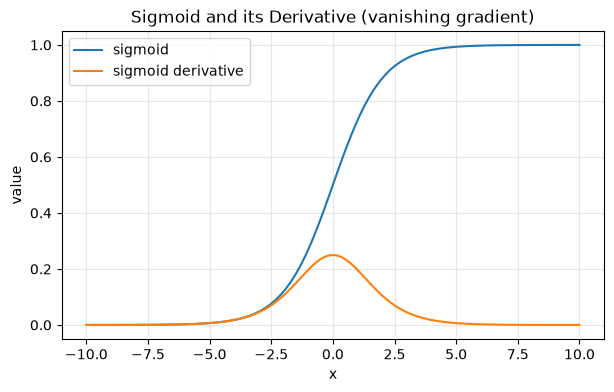

Max sigmoid derivative: 0.249 (at x=0)
For large |x|, the derivative approaches 0 -> gradients vanish.


In [10]:
# Vanishing gradient with sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid: sigmoid(x) * (1 - sigmoid(x))
x = np.linspace(-10, 10, 100)
s = sigmoid(x)
ds = s * (1 - s)

plt.figure(figsize=(7, 4))
plt.plot(x, s, label="sigmoid")
plt.plot(x, ds, label="sigmoid derivative")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Sigmoid and its Derivative (vanishing gradient)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Max sigmoid derivative: {ds.max():.3f} (at x=0)")
print("For large |x|, the derivative approaches 0 -> gradients vanish.")

## 14. Hands-On Practice

**Level 1 — Recall:** What does the derivative of a function measure? What does a gradient of zero mean?

**Level 2 — Apply:** Compute the partial derivatives of `f(x,y) = x²y + y³` at point (2, 1) by hand.

**Level 3 — Compute:** Use PyTorch autograd to compute the gradient of `f(x,y) = x²y + y³` at (2, 1). Verify your hand calculation.

**Level 4 — Debug:** This code produces `None` for the gradient. Why?
```python
x = torch.tensor(3.0)
y = x ** 2
y.backward()
print(x.grad)  # None!
```

**Level 5 — Create:** Compute the gradient of MSE loss `L = (1/n)Σ(wx + b - y)²` with respect to `w` and `b` using PyTorch. Compare with the analytical formulas.

## 15. Real-World ML Application

**How training actually works:**
```python
for epoch in range(100):
    y_pred = model(X)           # forward pass
    loss = mse_loss(y_pred, y)  # compute loss
    loss.backward()             # compute gradients (backpropagation)
    optimizer.step()            # update weights using gradients
    optimizer.zero_grad()       # reset gradients for next iteration
```

**The gradient tells us:**
- `∂Loss/∂w > 0`: increasing `w` increases loss → decrease `w`
- `∂Loss/∂w < 0`: increasing `w` decreases loss → increase `w`
- `∂Loss/∂w ≈ 0`: we're near a minimum

**Numerical gradients** are used for **gradient checking** — verifying that autograd produces correct results.

## 16. Debugging: Common Errors

**Gradient is None:**
```python
# WRONG: requires_grad defaults to False
x = torch.tensor(3.0)

# RIGHT:
x = torch.tensor(3.0, requires_grad=True)
```

**Numerical instability in derivatives:**
```python
# h too small → floating point errors
(f(x + 1e-10) - f(x - 1e-10)) / (2 * 1e-10)  # garbage

# h too large → poor approximation
(f(x + 1) - f(x - 1)) / 2  # very rough

# Sweet spot: h ≈ 1e-6 to 1e-8
```

## 17. Knowledge Check

Answer without running code:

1. What is the derivative of `f(x) = 5x³ - 2x + 1` at `x = 1`?
2. If the gradient at a point is `[0.5, -0.3]`, which direction should you move to minimize the function?
3. Why does the chain rule matter for neural networks?
4. What is the maximum derivative of the sigmoid function? What happens to gradients for large inputs?
5. Why does ReLU help with vanishing gradients?

## 18. Exit Criteria

You're ready to move on when you can:
- [ ] Compute numerical derivatives and verify against analytical formulas
- [ ] Explain what partial derivatives and the gradient represent
- [ ] Apply the chain rule to simple composite functions
- [ ] Use PyTorch autograd to compute gradients
- [ ] Explain why vanishing gradients are a problem and how ReLU helps
- [ ] Connect derivatives to how neural networks actually learn

## 19. Next Step

**→ 02.4 Gradient Descent**: Now that you understand gradients, learn the optimization algorithm that uses them — gradient descent and its variants (SGD, Adam).